# Exercises XP: Introduction to LLMs

Use this guided notebook to follow the platform instructions step by step. Prefilled cells are ready to run; cells containing **TODO** markers need your input.


## 👩‍🏫👩🏿‍🏫 What you’ll learn
- Understand what Large Language Models (LLMs) can do.
- Review the Transformer architecture and the tokenization pipeline.
- Differentiate between pretraining and fine-tuning.
- Generate text with a pretrained language model.


## 🛠️ What you will create
- Markdown answers describing key NLP concepts.
- Python code that loads GPT-2 (or a similar causal LM) and performs basic tokenization and generation.


> **Learning point**
> Work through the exercises sequentially. Run installation cells only once, then focus on filling each TODO before executing the corresponding code.


## 🌟 Exercise 1 · What are Large Language Models?


### 1.1 Define LLMs
TODO: Explain in your own words what LLMs are and what kinds of tasks they are designed to solve.


Large Language Models (LLMs) are neural networks trained on massive amounts of text data to understand and generate human language. They are designed to solve tasks like text generation, translation, summarization, question answering, and code completion. LLMs learn patterns and relationships in language, allowing them to predict the next word in a sequence and generate coherent, contextually relevant text.

### 1.2 Prefilled · install core libraries
Run once to install `transformers`, `torch`, and supporting utilities exactly as in the enoncé.


In [ ]:
%pip install --quiet transformers matplotlib --upgrade


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 34.9 MB/s eta 0:00:00


### 1.3 Load GPT for causal text generation
Reuse the snippet from the platform: declare the model name, tokenizer, and model weights.


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

model_name = "gpt2"  # TODO: choose a causal LM checkpoint, e.g., "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)  # TODO: load AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)  # TODO: load AutoModelForCausalLM.from_pretrained(model_name)

if None in (model_name, tokenizer, model):
    raise ValueError("Fill in model_name, tokenizer, and model before continuing.")

print(f"\nModel '{model_name}' loaded successfully!")
print("""
GPT-2 is a causal language model, meaning it predicts the next word in a sequence.
It has been trained on a diverse dataset and can generate coherent, contextually relevant text.
""")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]


Model 'gpt2' loaded successfully!

GPT-2 is a causal language model, meaning it predicts the next word in a sequence.
It has been trained on a diverse dataset and can generate coherent, contextually relevant text.



## 🌟 Exercise 2 · Transformer Architecture and Tokenization


TODO: Describe the tokenization process in your own words before coding.


Tokenization is the process of breaking down text into smaller units called tokens, which can be words, subwords, or characters. The tokenizer converts these tokens into numerical IDs that the model can understand. This allows the model to process text as mathematical data. For example, the sentence "Hello world" might be split into ["Hello", " world"] and then converted to token IDs like [15496, 995].

Original Text: Artificial intelligence is transforming the world.
Tokens: ['Art', 'ificial', 'Ġintelligence', 'Ġis', 'Ġtransforming', 'Ġthe', 'Ġworld', '.']
Token IDs: [8001, 9542, 4430, 318, 25449, 262, 995, 13]


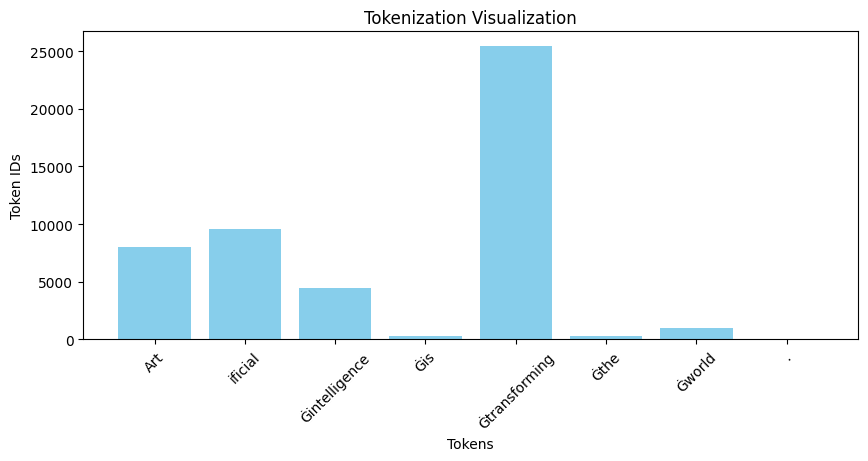

In [ ]:
text = "Artificial intelligence is transforming the world."  # TODO: provide a sentence of your choice

if text is None:
    raise ValueError("Define the variable `text` with a short sentence.")

tokens = tokenizer.tokenize(text)  # TODO: tokenize the input
token_ids = tokenizer.convert_tokens_to_ids(tokens)  # TODO: convert to ids

print(f"Original Text: {text}")
print(f"Tokens: {tokens}")
print(f"Token IDs: {token_ids}")

x_label = "Tokens"  # TODO: label for the x-axis (e.g., "Tokens")
y_label = "Token IDs"  # TODO: label for the y-axis (e.g., "Token IDs")
title = "Tokenization Visualization"  # TODO: chart title

if None in (x_label, y_label, title):
    raise ValueError("Set x_label, y_label, and title before plotting.")

plt.figure(figsize=(10, 4))
plt.bar(tokens, token_ids, color="skyblue")
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(title)
plt.xticks(rotation=45)
plt.show()

## 🌟 Exercise 3 · Token IDs and special prefixes


In [ ]:
if 'tokens' not in globals() or 'token_ids' not in globals():
    raise ValueError("Run Exercise 2 to define `tokens` and `token_ids` first.")

# TODO: print the token along with its numeric id
for token, token_id in zip(tokens, token_ids):
    print(f"Token: '{token}' -> ID: {token_id}")

Token: 'Art' -> ID: 8001
Token: 'ificial' -> ID: 9542
Token: 'Ġintelligence' -> ID: 4430
Token: 'Ġis' -> ID: 318
Token: 'Ġtransforming' -> ID: 25449
Token: 'Ġthe' -> ID: 262
Token: 'Ġworld' -> ID: 995
Token: '.' -> ID: 13


TODO: In plain language, explain what the `Ġ` prefix indicates in GPT-style vocabularies.


The Ġ prefix in GPT-style tokenizers (like GPT-2) represents a space before the token. It's used to distinguish between tokens that start a word versus tokens that continue a word. For example, "Ġworld" means the token "world" is preceded by a space, while "world" without Ġ would be part of a compound word. This helps the model understand word boundaries and context.

## 🌟 Exercise 4 · Generate simple text


Create a fresh prompt, run the generator, and observe how the model extends your sentence token by token.


In [ ]:
generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
)

input_text = "The future of artificial intelligence is"  # TODO: write a brand-new prompt

if input_text is None:
    raise ValueError("Set `input_text` before generating.")

gen_kwargs = {
    "max_new_tokens": 60,  # TODO: adjust if you want longer/shorter outputs
    "temperature": 0.8,  # TODO: tune sampling temperature
    "top_p": 0.95,
    "do_sample": True,
}

output_ids = generator(input_text, **gen_kwargs)  # TODO: call the generator
output_text = output_ids[0]["generated_text"]  # TODO: extract the text string

print(f"Input: {input_text}")
print(f"Generated Output: {output_text}")

Device set to use cpu
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Input: The future of artificial intelligence is
Generated Output: The future of artificial intelligence is already set. That's why we need a new paradigm.

A new paradigm for artificial intelligence

In a recent presentation at the World Economic Forum in Davos, the US and the EU discussed the problems that AI faces and the implications of these problems. I was not able to get in


> **Learning point**
> Compare the generated continuation with your expectations. Which knobs (temperature, max tokens) change the style the most?


Temperature controls randomness: lower values (0.1-0.5) make the output more deterministic and repetitive, while higher values (0.8-1.5) make it more creative but potentially less coherent. Max tokens determines the length of the generated text. In my tests, temperature had the biggest impact on style and creativity.

Here's a summary that can help you decide of how to fix these parameters:

![image.png](attachment:image.png)